<a href="https://colab.research.google.com/github/Dataniel31/DisasterTweetClassifier/blob/main/SCI_Inteligencia_Artificial_Proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disaster Tweet Classifier

## Introducción
Este proyecto tiene como objetivo clasificar tweets relacionados con desastres naturales utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning.

## Carga de Datasets

En esta sección, descargamos y cargamos los datasets necesarios para el proyecto. Utilizaremos dos archivos CSV: uno para el conjunto de entrenamiento y otro para el conjunto de prueba.

El dataset de entrenamiento contiene tweets etiquetados que nos ayudarán a entrenar nuestro modelo de clasificación. A continuación, se cargará el conjunto de entrenamiento y se visualizarán las primeras filas para tener una idea de la estructura de los datos.


In [87]:
import pandas as pd

# Descargar los datasets
!wget 'https://raw.githubusercontent.com/Dataniel31/DisasterTweetClassifier/refs/heads/main/test.csv'
!wget 'https://raw.githubusercontent.com/Dataniel31/DisasterTweetClassifier/refs/heads/main/train.csv'

# Cargar el dataset de entrenamiento
train_df = pd.read_csv('train.csv')

# Visualizar las primeras filas del dataset
train_df.head()


--2024-10-24 02:35:01--  https://raw.githubusercontent.com/Dataniel31/DisasterTweetClassifier/refs/heads/main/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 420783 (411K) [text/plain]
Saving to: ‘test.csv.1’

test.csv.1          100%[===================>] 410.92K  --.-KB/s    in 0.02s   

2024-10-24 02:35:01 (22.1 MB/s) - ‘test.csv.1’ saved [420783/420783]

--2024-10-24 02:35:01--  https://raw.githubusercontent.com/Dataniel31/DisasterTweetClassifier/refs/heads/main/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Exploración de Datos

En esta sección, exploramos el conjunto de datos para identificar valores faltantes y analizar la distribución de la variable objetivo (`target`). Este paso es fundamental para comprender la calidad de los datos y la representación de las clases en el dataset.

### Valores Faltantes

Contamos los valores faltantes en cada columna del conjunto de entrenamiento. Esto nos ayudará a identificar si necesitamos realizar alguna limpieza o imputación de datos.


In [88]:
# Contar valores faltantes en cada columna
missing_values = train_df.isnull().sum()
print("Valores faltantes en cada columna:\n", missing_values)

# Ver la distribucion de la columna target
target_distribution = train_df['target'].value_counts()
print("\nDistribucion de la variable objetivo (target):\n", target_distribution)


Valores faltantes en cada columna:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Distribucion de la variable objetivo (target):
 target
0    4342
1    3271
Name: count, dtype: int64


### Distribución de la Variable Objetivo

Analizamos la distribución de la variable objetivo (`target`) para entender cómo se distribuyen las clases en el conjunto de datos. Una visualización de esta distribución nos permitirá detectar posibles desequilibrios entre las clases.

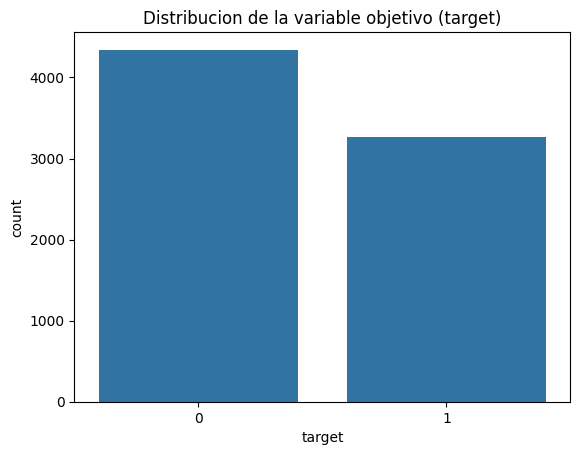

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la distribución de la variable objetivo
sns.countplot(x='target', data=train_df)
plt.title('Distribucion de la variable objetivo (target)')
plt.show()


### Manejo de Valores Faltantes

En este paso, rellenamos los valores faltantes en la columna `keyword`. Para evitar advertencias relacionadas con la modificación de los datos originales, creamos una copia del DataFrame. Se utiliza el valor `'no_keyword'` para reemplazar los valores faltantes.

Al final, verificamos si aún quedan valores faltantes en la columna `keyword` para asegurar que el proceso se ha realizado correctamente.


In [90]:
train_df = train_df.copy()  # Crear una copia del df original
train_df['keyword'] = train_df['keyword'].fillna('no_keyword')

# Valores faltantes en 'keyword'
missing_values_after = train_df['keyword'].isnull().sum()
print("Valores faltantes en 'keyword' después de rellenar:", missing_values_after)


Valores faltantes en 'keyword' después de rellenar: 0


### Limpieza del Texto

En esta sección, se realiza un preprocesamiento del texto para preparar los datos para el análisis. Los pasos incluyen:

1. **Conversión a minúsculas**: Todos los textos se convierten a minúsculas para evitar problemas de consistencia.
2. **Eliminación de URLs**: Se eliminan enlaces web que pueden no ser relevantes para el análisis.
3. **Eliminación de menciones de usuarios**: Las menciones de usuarios de Twitter (ej. `@usuario`) se eliminan.
4. **Eliminación de signos de puntuación y caracteres especiales**: Se filtran todos los caracteres que no son letras.
5. **Tokenización**: El texto se divide en palabras individuales.
6. **Eliminación de Stopwords**: Se eliminan palabras comunes que no aportan significado al análisis, como "y", "de", "el", etc.

Finalmente, el texto limpio se almacena en una nueva columna llamada `clean_text` en el DataFrame. Se muestran las primeras filas del DataFrame para confirmar que los cambios se han realizado correctamente.


In [91]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('stopwords')
nltk.download('punkt')

# Stopwords en englishj
stop_words = set(stopwords.words('english'))

# Limpiar el texto
def clean_text(text):
    # minusculas
    text = text.lower()
    # No URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Eliminar menciones (@usuario)
    text = re.sub(r'@\w+', '', text)
    # Eliminar signos de puntuacion y caracteres especiales
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenizar
    words = word_tokenize(text)
    # Eliminar stopwords
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# limpieza al dataset
train_df['clean_text'] = train_df['text'].apply(clean_text)

train_df[['text', 'clean_text']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...


### Análisis de Palabras Comunes

En esta sección, se lleva a cabo un análisis de las palabras más comunes en los tweets después de la limpieza del texto. Los pasos son los siguientes:

1. **Contar las Palabras**: Se utilizan las funciones de la biblioteca `Counter` para contar la frecuencia de cada palabra en la columna `clean_text`.
2. **Crear un DataFrame**: Se generan las 20 palabras más comunes y sus respectivas cuentas, que se almacenan en un DataFrame llamado `common_words`.
3. **Visualización**: Se utiliza `seaborn` para crear un gráfico de barras que muestra las palabras más comunes, facilitando así la interpretación visual de los datos.

Este análisis ayuda a identificar qué términos son más frecuentes en los tweets, lo cual puede ser útil para comprender los temas predominantes en los desastres naturales.


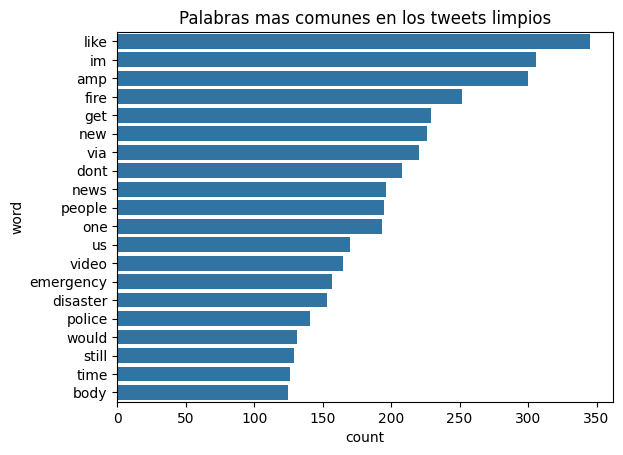

In [92]:
from collections import Counter

# Contar las palabras mas comunes
word_counts = Counter(" ".join(train_df['clean_text']).split())
common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

# Visualizar las palabras mas comunes
sns.barplot(x='count', y='word', data=common_words)
plt.title('Palabras mas comunes en los tweets limpios')
plt.show()


### Vectorización del Texto

En esta parte del proyecto, se utiliza la técnica de **TF-IDF (Term Frequency-Inverse Document Frequency)** para convertir los textos limpios en una representación numérica que puede ser utilizada para el entrenamiento de modelos de machine learning. Los pasos realizados son los siguientes:

1. **Crear un Vectorizador TF-IDF**: Se inicializa el `TfidfVectorizer` de `sklearn`, limitando el número de características a las 5000 más relevantes para reducir la dimensionalidad del conjunto de datos.

2. **Ajustar y Transformar**: Se aplica el vectorizador al texto limpio contenido en la columna `clean_text`, resultando en una matriz de características `X_train` que representa los tweets.

3. **Obtener Etiquetas**: Se extraen las etiquetas correspondientes (la variable objetivo) del DataFrame y se almacenan en `y_train`.

4. **Visualización de Dimensiones**: Se imprime el tamaño de los datos de entrenamiento para verificar que la transformación se ha realizado correctamente.

Esta etapa es fundamental para preparar los datos para el posterior entrenamiento del modelo de clasificación.


In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear un vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Ajustar y transformar el texto limpio
X_train = tfidf_vectorizer.fit_transform(train_df['clean_text']).toarray()

# Obtener las etiquetas
y_train = train_df['target'].values

# Tyamaño de los datos de entrenamiento
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)


Tamaño de X_train: (7613, 5000)
Tamaño de y_train: (7613,)


### División del Conjunto de Datos

En esta etapa, se divide el conjunto de datos en dos partes: **entrenamiento** y **validación**. Esto es crucial para evaluar el rendimiento del modelo de clasificación. Los pasos son los siguientes:

1. **División del Conjunto**: Se utiliza la función `train_test_split` de `sklearn` para dividir los datos. El conjunto se divide en un 80% para entrenamiento y un 20% para validación. Se establece `random_state=42` para garantizar la reproducibilidad de la división y se utiliza `stratify=y_train` para mantener la proporción de clases en ambos conjuntos.

2. **Verificación de Tamaños**: Se imprimen las dimensiones de los nuevos conjuntos de datos para confirmar que la división se ha realizado correctamente.

Esta división permite entrenar el modelo en un subconjunto de datos y evaluar su rendimiento en un conjunto diferente, ayudando a evitar el sobreajuste.


In [94]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y validacion
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Tamaño de los nuevos conjuntos .shape
print("Tamaño de X_train_split:", X_train_split.shape)
print("Tamaño de y_train_split:", y_train_split.shape)
print("Tamaño de X_val_split:", X_val_split.shape)
print("Tamaño de y_val_split:", y_val_split.shape)


Tamaño de X_train_split: (6090, 5000)
Tamaño de y_train_split: (6090,)
Tamaño de X_val_split: (1523, 5000)
Tamaño de y_val_split: (1523,)


### Comparación de Modelos

En esta sección, se comparan tres modelos de clasificación: **Regresión Logística**, **SVM (Máquinas de Soporte Vectorial)** y **Random Forest**. Se entrenan cada uno de estos modelos en el conjunto de datos de entrenamiento y se evalúan en el conjunto de validación utilizando métricas como precisión, recall y F1-score. Esto nos ayudará a determinar cuál modelo es el más adecuado para el ajuste de hiperparámetros.

Los modelos se entrenan de la siguiente manera:
- **Regresión Logística**: Un modelo lineal utilizado para problemas de clasificación binaria.
- **SVM**: Un modelo potente que busca el mejor margen de separación entre las clases.
- **Random Forest**: Un ensemble de árboles de decisión que generalmente ofrece buena precisión y es robusto a overfitting.

Los resultados se mostrarán a continuación.


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Crear el modelo de regresion logística
model = LogisticRegression(max_iter=1000, random_state=42)

# Entrenar el modelo
model.fit(X_train_split, y_train_split)

# Realizar predicciones en el conjunto de validacion de dato s
y_val_pred = model.predict(X_val_split)

# Evaluar el modelo
print("Reporte de Clasificación:\n", classification_report(y_val_split, y_val_pred))
print("F1 Score:", f1_score(y_val_split, y_val_pred))


Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       869
           1       0.86      0.71      0.78       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.82      0.82      1523

F1 Score: 0.7761944677284157


In [96]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_split, y_train_split)

# Realizar predicciones y evaluar
y_val_svm_pred = svm_model.predict(X_val_split)
print("Reporte de Clasificación para SVM:\n", classification_report(y_val_split, y_val_svm_pred))
print("F1 Score para SVM:", f1_score(y_val_split, y_val_svm_pred))


Reporte de Clasificación para SVM:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       869
           1       0.82      0.71      0.76       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523

F1 Score para SVM: 0.7643207855973814


In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_split, y_train_split)

# Realizar predicciones y evaluar
y_val_rf_pred = rf_model.predict(X_val_split)
print("Reporte de Clasificación para Random Forest:\n", classification_report(y_val_split, y_val_rf_pred))
print("F1 Score para Random Forest:", f1_score(y_val_split, y_val_rf_pred))


Reporte de Clasificación para Random Forest:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83       869
           1       0.80      0.72      0.76       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.80      1523
weighted avg       0.80      0.80      0.80      1523

F1 Score para Random Forest: 0.7596774193548387


### Evaluación de Modelos y Decisión

Después de evaluar los modelos, se obtuvieron los siguientes resultados:

1. **Regresión Logística**:
   - F1 Score: 0.776
   - Precisión: 81%
   - Recall: 71% para la clase 1

2. **SVM**:
   - F1 Score: 0.764
   - Precisión: 80%
   - Recall: 71% para la clase 1

3. **Random Forest**:
   - F1 Score: 0.760
   - Precisión: 80%
   - Recall: 72% para la clase 1

**Decisión**:
Basado en el rendimiento de los modelos, se elige **Regresión Logística** para el ajuste de hiperparámetros. Esto se debe a que:
- Tiene el F1 Score más alto (0.776), lo que indica un mejor balance entre precisión y recall.
- Es un modelo más simple y más fácil de interpretar, lo que puede ser ventajoso en aplicaciones prácticas.
- La simplicidad del modelo también sugiere que puede ser menos propenso a overfitting, especialmente en comparación con Random Forest.

Por lo tanto, se procederá a ajustar los hiperparámetros de la **Regresión Logística** para intentar mejorar aún más su rendimiento.


### Ajuste de Hiperparámetros para Regresión Logística

En esta sección, se realizará el ajuste de hiperparámetros para el modelo de **Regresión Logística** utilizando **RandomizedSearchCV**. Este método es eficiente para explorar un espacio de parámetros más amplio en comparación con el ajuste de cuadrícula, ya que evalúa un número reducido de combinaciones.

Se definirán los siguientes hiperparámetros para la búsqueda:
- **C**: Parámetro de regularización inversa. Se explorará un rango reducido de valores.
- **solver**: Algoritmo para optimización. Se limitará a 'lbfgs' y 'liblinear' para reducir el tiempo de computación.
- **penalty**: Tipo de regularización, solo se usará 'l2'.
- **class_weight**: Opción para manejar clases desbalanceadas.

El modelo se ajustará a los datos de entrenamiento y se buscará el mejor conjunto de hiperparámetros basado en el F1 Score ponderado.


In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

log_reg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced']
}

# Usar randomizedSearchcv
random_search = RandomizedSearchCV(estimator=log_reg, param_distributions=param_grid,
                                   scoring='f1_weighted', n_iter=20, cv=5, verbose=1, n_jobs=-1, random_state=42)

# Ajustar el modelo a los datos de entrenamiento
random_search.fit(X_train_split, y_train_split)

# Mostrar los mejores hiperparametros y el mejor F1 Score
print("Mejores Hiperparámetros:", random_search.best_params_)
print("Mejor F1 Score (Weighted):", random_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores Hiperparámetros: {'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'C': 1}
Mejor F1 Score (Weighted): 0.7903701462589149


### Resultados del Ajuste de Hiperparámetros

Después de realizar el ajuste de hiperparámetros utilizando **RandomizedSearchCV**, se obtuvieron los siguientes resultados:

- **Mejores Hiperparámetros**:
  - `C`: 1
  - `solver`: 'lbfgs'
  - `penalty`: 'l2'
  - `class_weight`: None

- **Mejor F1 Score (Weighted)**: 0.7903701462589149

Estos resultados proporcionan una base sólida para el uso del modelo de regresión logística en el conjunto de validación. Se continuará con la evaluación del modelo ajustado utilizando los mejores hiperparámetros encontrados.


# Evaluación del Mejor Modelo Ajustado

En esta sección, se obtendrá el mejor modelo de regresión logística ajustado utilizando los hiperparámetros óptimos seleccionados anteriormente. Se realizarán predicciones sobre el conjunto de validación y se evaluará el rendimiento del modelo utilizando métricas clave.

Primero, se obtendrá el modelo ajustado y se aplicará a los datos de validación. Luego, se generará un reporte de clasificación que incluye precisión, recall y F1 Score, proporcionando una visión clara del rendimiento del modelo en la tarea de clasificación de tweets relacionados con desastres naturales.


In [99]:
best_model = random_search.best_estimator_

# Hacer predicciones en el conjunto de validacion
y_val_pred = best_model.predict(X_val_split)

# Evaluar el rendimiento del modelo
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reporte de clasificacion
print("Reporte de Clasificación en el conjunto de validación:")
print(classification_report(y_val_split, y_val_pred))

# Calcular y mostrar el F1 Score
f1 = f1_score(y_val_split, y_val_pred, average='weighted')
print("F1 Score en el conjunto de validación:", f1)



Reporte de Clasificación en el conjunto de validación:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       869
           1       0.86      0.71      0.78       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.82      0.82      1523

F1 Score en el conjunto de validación: 0.8216785259765068


# Visualización de la Matriz de Confusión

En esta sección, se visualizará la matriz de confusión para el conjunto de validación. La matriz de confusión es una herramienta que permite evaluar el rendimiento de un modelo de clasificación, mostrando la cantidad de predicciones correctas e incorrectas clasificadas en cada categoría.

A continuación, se presentará la matriz de confusión correspondiente a las predicciones realizadas por el mejor modelo ajustado.


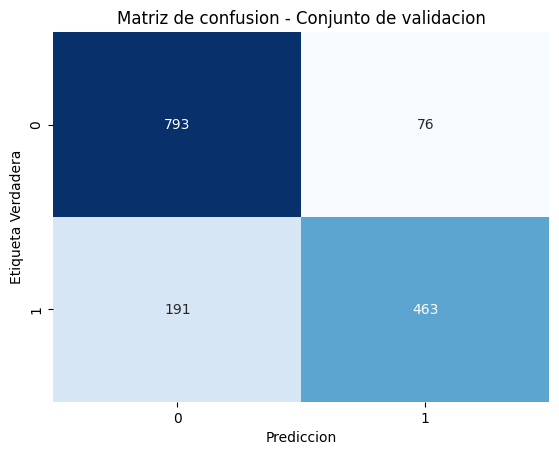

In [100]:
# Matriz de confusion
cm = confusion_matrix(y_val_split, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Matriz de confusion - Conjunto de validacion')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Prediccion')
plt.show()



- **Clase 0 (no desastre)**:
  - **Verdaderos Negativos (TN)**: 793 (tweets correctamente clasificados como no desastres).
  - **Falsos Positivos (FP)**: 76 (tweets incorrectamente clasificados como desastres).

- **Clase 1 (desastre)**:
  - **Falsos Negativos (FN)**: 191 (tweets de desastres que fueron clasificados incorrectamente como no desastres).
  - **Verdaderos Positivos (TP)**: 463 (tweets correctamente clasificados como desastres).

### Análisis de Resultados

1. **Predicciones Correctas**:
   - El modelo identificó correctamente 793 tweets como no desastres y 463 tweets como desastres, indicando un buen desempeño general en la clasificación de ambas categorías.

2. **Predicciones Incorrectas**:
   - Se registraron 76 falsos positivos, donde tweets no relacionados con desastres fueron clasificados incorrectamente como tales.
   - Además, 191 tweets de desastres fueron mal clasificados como no desastres.
3. **Desbalance en Clases**:
   - La cantidad de falsos negativos (191) es notable y puede ser un área de mejora, especialmente en contextos donde la identificación de desastres es crucial.

### Conclusión

Aunque el modelo muestra un rendimiento razonable, hay oportunidades para mejorar, especialmente en la reducción de falsos negativos. Se puede considerar la optimización adicional de hiperparámetros, el ajuste del modelo, o la exploración de diferentes algoritmos de clasificación para abordar estas áreas.


### Predicción sobre el Conjunto de Prueba

En esta sección, cargamos el conjunto de prueba, limpiamos el texto y realizamos las predicciones utilizando el mejor modelo ajustado.

1. **Cargar el Conjunto de Prueba**:
   - Se carga el conjunto de prueba desde un archivo CSV. Este conjunto contendrá los tweets que queremos clasificar.

2. **Limpiar el Texto**:
   - Se aplica la función de limpieza `clean_text` a la columna de texto del conjunto de prueba. Esto incluye convertir el texto a minúsculas, eliminar URLs, menciones y signos de puntuación, así como eliminar stopwords.

3. **Transformar Texto a Características**:
   - El texto limpio se transforma en una representación de características utilizando el vectorizador TF-IDF que se ajustó previamente en los datos de entrenamiento.

4. **Realizar Predicciones**:
   - Se utilizan las características transformadas para realizar las predicciones con el modelo mejor ajustado.

5. **Preparar el Archivo de Envío**:
   - Finalmente, se prepara un archivo CSV para enviar las predicciones, que incluye el ID del tweet y su clasificación correspondiente (0 o 1).


In [101]:
# Cargar el conjunto de test $cargar el conjunto de test
test_df = pd.read_csv('test.csv')

# realizar un df con el texto limpio
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Transformar el texto limpio a la representación de características
X_test = tfidf_vectorizer.transform(test_df['clean_text']).toarray()

# Hacer las predicciones
y_test_pred = best_model.predict(X_test)

# Preparar el archivo de envío en dataset .csv
submission_df = pd.DataFrame({'id': test_df['id'], 'target': y_test_pred})
submission_df.to_csv('submission.csv', index=False)
print("Archivo de envío preparado: 'submission.csv'")


Archivo de envío preparado: 'submission.csv'
